<a href="https://colab.research.google.com/github/fdx-hw/cosc-650/blob/week_2_inference_sampling/week2_inference_sampling_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 (starter): Inference and Sampling

Runs as-is on a small local model so you can see each stage; cells marked **TODO (you)** are where you do the work. No GPU, no API key. Dependencies: `transformers`, `torch` (CPU), `numpy`, `matplotlib`.

Parts: trace the forward pass, build the sampling explorer, evaluate three settings, find one failure, submit.

In [1]:
# Setup. In Colab: !pip install transformers torch numpy matplotlib
import os, pathlib
os.environ['HF_HOME'] = str((pathlib.Path('.') / '.hf_cache').resolve())
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
torch.manual_seed(0)
name = 'distilgpt2'
tok = AutoTokenizer.from_pretrained(name)
model = AutoModelForCausalLM.from_pretrained(name, attn_implementation='eager')  # eager so attention is returned
model.eval()
cfg = model.config
print(f'{name}: {cfg.n_layer} layers, {cfg.n_head} heads, embed dim {cfg.n_embd}, vocab {cfg.vocab_size}')

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

distilgpt2: 6 layers, 12 heads, embed dim 768, vocab 50257


## Discussion Post Settings Experiment

In [28]:
def generate(prompt, temperature=1.0, top_k=None, top_p=None, max_new_tokens=30, greedy=False):
    enc = tok(prompt, return_tensors='pt')
    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=not greedy,
            temperature=temperature if not greedy else None,
            top_k=top_k,
            top_p=top_p,
            pad_token_id=tok.eos_token_id,
        )
    return tok.decode(out[0], skip_special_tokens=True)

prompt = "The scientist stared at the readings in disbelief. She had never seen"

print('--- Temperature 0 (greedy) ---')
print(generate(prompt, greedy=True))
print('\n--- Temperature 0.7, top-p 0.9 ---')
print(generate(prompt, temperature=0.7, top_p=0.9))
print('\n--- Temperature 1.2, top-k 50 ---')
print(generate(prompt, temperature=1.2, top_k=50))

--- Temperature 0 (greedy) ---
The scientist stared at the readings in disbelief. She had never seen a single one of the readings.


"I don't know what the hell is going on," she said. "I don't know

--- Temperature 0.7, top-p 0.9 ---
The scientist stared at the readings in disbelief. She had never seen a man with a wavy hair. But she had been able to tell the truth.


"A human being is a human being,

--- Temperature 1.2, top-k 50 ---
The scientist stared at the readings in disbelief. She had never seen the data before – which looked too little. She could see the dark energy behind everything, not only a certain amount of space, yet it all seemed


## Part 1: Trace the forward pass
**TODO (you):** change the prompt to your own. Read off the real numbers at each stage.

In [2]:
prompt = 'The tallest skyscraper in the world is'   # TODO (you): your own short prompt
enc = tok(prompt, return_tensors='pt')
ids = enc['input_ids'][0]
print('token IDs:', ids.tolist())
for i, t in enumerate(ids.tolist()):
    print(f'  pos {i}: id {t:6d} -> {tok.decode([t])!r}')

emb = model.transformer.wte(ids)
print('\nembedded prompt shape (seq_len, dim):', tuple(emb.shape))

with torch.no_grad():
    out = model(**enc, output_attentions=True)
att = out.attentions[0][0, 0, -1]   # layer 0, head 0, last token attends to...
print('last-token attention (layer 0, head 0), sums to', round(att.sum().item(), 4))
for j in range(ids.shape[0]):
    print(f'  {tok.decode([ids[j]])!r:12s} {att[j].item():.3f}')

with torch.no_grad():
    logits = model(**enc).logits
print('\nlogits shape (batch, seq, vocab):', tuple(logits.shape))
probs = torch.softmax(logits[0, -1], dim=-1)
top = torch.topk(probs, 10)
print('top 10 next tokens:')
for p, idx in zip(top.values.tolist(), top.indices.tolist()):
    print(f'  {tok.decode([idx])!r:14s} {p:.4f}')
next_logits = logits[0, -1]

token IDs: [464, 38760, 37885, 38545, 287, 262, 995, 318]
  pos 0: id    464 -> 'The'
  pos 1: id  38760 -> ' tallest'
  pos 2: id  37885 -> ' skysc'
  pos 3: id  38545 -> 'raper'
  pos 4: id    287 -> ' in'
  pos 5: id    262 -> ' the'
  pos 6: id    995 -> ' world'
  pos 7: id    318 -> ' is'

embedded prompt shape (seq_len, dim): (8, 768)
last-token attention (layer 0, head 0), sums to 1.0
  'The'        0.329
  ' tallest'   0.139
  ' skysc'     0.159
  'raper'      0.180
  ' in'        0.038
  ' the'       0.042
  ' world'     0.067
  ' is'        0.046

logits shape (batch, seq, vocab): (1, 8, 50257)
top 10 next tokens:
  ' the'         0.2764
  ' located'     0.0370
  ' now'         0.0296
  ' in'          0.0258
  ' a'           0.0241
  ' at'          0.0218
  ' built'       0.0185
  ' The'         0.0127
  ' currently'   0.0092
  ' on'          0.0087


## Part 2: Build the sampling explorer
Temperature, top-k, and top-p over the model's real next-token distribution.

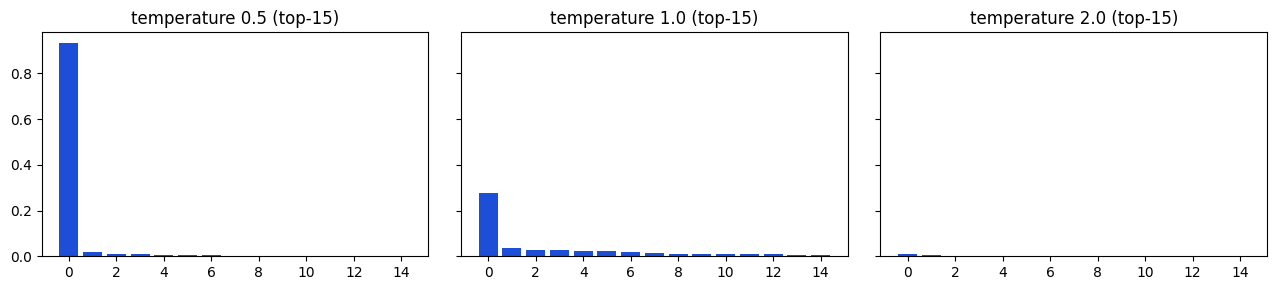

top token prob: temp 0.5 = 0.933, temp 1.0 = 0.276, temp 2.0 = 0.010


In [3]:
import numpy as np, matplotlib.pyplot as plt
z = next_logits.detach().numpy()

def softmax(x):
    x = x - x.max(); e = np.exp(x); return e / e.sum()
def temperature(z, t):
    return softmax(z / t)
def top_k(p, k):
    out = np.zeros_like(p); idx = np.argsort(p)[::-1][:k]; out[idx] = p[idx]; return out / out.sum()
def top_p(p, thresh):
    order = np.argsort(p)[::-1]; cdf = np.cumsum(p[order]); cut = np.searchsorted(cdf, thresh) + 1
    out = np.zeros_like(p); out[order[:cut]] = p[order[:cut]]; return out / out.sum(), cut

base = softmax(z)
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
for ax, t in zip(axes, [0.5, 1.0, 2.0]):
    pt = temperature(z, t)
    ax.bar(range(15), np.sort(pt)[::-1][:15], color='#1d4ed8')
    ax.set_title(f'temperature {t} (top-15)')
plt.tight_layout(); plt.show()
print('top token prob: temp 0.5 = %.3f, temp 1.0 = %.3f, temp 2.0 = %.3f' % (
    temperature(z,0.5).max(), temperature(z,1.0).max(), temperature(z,2.0).max()))

## Part 3: Evaluate three settings with real figures
Predict first, then read the entropy, the maximum probability, and how many tokens survive.

Before running the cell, here's what I expected for each setting:

* **temp basically 0, top-p 1.0** → With such a low temperature, the model
  should act almost like it's always picking its single most confident
  answer, no randomness at all. So I'd expect very low uncertainty, close to
  100% confidence in one token, and only a tiny handful of tokens (maybe just
  one) being considered.

* **temp 0.7, top-p 1.0** → This is a bit more confident than the
  model's normal default setting, so I'd expect the model to lean fairly
  strongly toward one answer, but with some room for other options too. So the model would have moderate uncertainty and decently high confidence in the top pick.

* **temp 1.3, top-p 0.9** → Higher temperature should make the model less
  confident and more spread out across many possible answers. So I'd expect
  more uncertainty, a lower confidence score for the top pick, and the model
  needing to consider a lot more tokens to cover 90% of the likely outcomes.

In [4]:
def entropy(p):
    p = p[p > 0]; return float(-(p * np.log(p)).sum())
for t, tp in [(1e-6, 1.0), (0.7, 1.0), (1.3, 0.9)]:
    p = temperature(z, t)
    _, kept = top_p(p, tp)
    print(f'temp {t:<6} top-p {tp}: entropy {entropy(p):.3f}, max prob {p.max():.3f}, nucleus keeps {kept} tokens')
# TODO (you): for each row, write what you predicted versus what you see.

temp 1e-06  top-p 1.0: entropy -0.000, max prob 1.000, nucleus keeps 1 tokens
temp 0.7    top-p 1.0: entropy 1.810, max prob 0.710, nucleus keeps 50258 tokens
temp 1.3    top-p 0.9: entropy 7.480, max prob 0.084, nucleus keeps 4982 tokens


## Part 3: Predicted vs. actual

**Setting 1 (temp basically 0, top-p 1.0):** I expected the model to just pick
its top choice every time with no randomness, since a near zero temperature
makes the model super confident. The model was 100% sure of one token, and kept only that single token.

**Setting 2 (temp 0.7, top-p 1.0):** I expected a fairly confident but not
extreme distribution and some randomness, but still leaning heavily toward one
answer. That part was right (71% confidence in the top token). What surprised
me was that "top-p 1.0" kept literally every single token in the vocabulary
(over 50,000 of them) as an option. At first that seems weird, how can the
model be 71% sure of one answer but still be "considering" 50,000 tokens?
The answer is that top-p 1.0 doesn't actually filter anything out, it's set
to include 100% of all possible outcomes, so it never removes any tokens no
matter how confident the model is. It's basically a setting that does nothing.

**Setting 3 (temp 1.3, top-p 0.9):** I expected the model to be much less
confident and more spread out across options, since higher temperature adds
more randomness. The model's top guess only had an 8% chance of being picked, and it needed to consider almost 5,000 different tokens just to cover 90% of the likely outcomes. This setting produces the most unpredictable, varied output of the three.

## Part 4: Find one failure and explain it (required)
**TODO (you):** show one surprising case and explain the cause and mitigation. A starter is below.

In [6]:
# starter failure: near-zero temperature collapses to a single token
p0 = temperature(z, 1e-6)
print('temp -> 0: top token prob =', round(p0.max(), 6), '(greedy collapse)')
p1, kept1 = top_p(temperature(z, 0.7), 1.0)
print('temp 0.7, top-p 1.0: max prob =', round(p1.max(), 3), ', nucleus keeps', kept1, 'tokens out of', len(p1))
# TODO (you): find your own surprising case (e.g. top-p = 1.0 keeps the whole vocab) and explain it.

temp -> 0: top token prob = 1.0 (greedy collapse)
temp 0.7, top-p 1.0: max prob = 0.71 , nucleus keeps 50258 tokens out of 50257


### Failure case: top-p 1.0 doesn't actually filter anything

**The surprise:** at temp 0.7, the model was pretty confident since one token had a 71% chance of being picked. You'd think with that much confidence, only a
few tokens would matter and get "kept" as real options. But the nucleus
(top-p) setting kept every single token in the vocabulary - all 50,258 of
them.

**Why it happens:** top-p works by adding up probabilities from the most
likely token downward until the total reaches whatever percentage you set
(the "p" value). If you set it to 1.0, that means "keep adding tokens until
you've covered 100% of all possibilities" - and since all the probabilities
in the whole vocabulary always add up to 100% no matter what, nothing ever
gets left out. So top-p 1.0 doesn't mean "only keep the confident options" -
it actually means "don't filter out anything at all." How confident the model
is (71% in this case) and how many tokens get kept are two completely
separate things once top-p is set to 1.0.

**Mitigation:** if you actually want to limit the model to its more likely
answers, top-p needs to be set below 1.0 (like 0.9). Setting it to 1.0 doesn't
make the output safer or more focused, it just turns the filter off
completely. It's easy to assume "1.0" sounds like the strictest or safest
setting, when it's actually the loosest one possible.

## Part 5: Submit
Run top to bottom on your prompt, then open a pull request with a result summary, the notebook, and a linked research-note issue. Rubric: trace (30), sampling explorer (25), three settings evaluated (20), failure case (15), PR hygiene (10).